In [1]:
import numpy as np
from qutip import *
from scipy.linalg import sqrtm, eigvalsh
import numba
from numba import njit, prange
import pickle
import os

## Fidelity
Generic definition : <br>
$ \mathcal{F}\left( \rho, \sigma \right) = \left( Tr \left[ \sqrt{ \sqrt{\rho} \sigma \sqrt{\rho} }\right] \right)^{2} $ <br>
Definition for Pure State : <br>
$ \mathcal{F}\left( \rho, \sigma \right) = |\langle \psi_{\rho} | \psi_{\sigma} \rangle|^{2} $ <br>
Definition for Qubits : <br>
$ \mathcal{F}\left( \rho, \sigma \right) = Tr\left( \rho \, \sigma \right) + 2 \sqrt{Det\left ( \rho \right) \, Det\left ( \sigma \right)} $ <br>
## Trace Distance
Generic definition : <br>
$ \mathcal{T}\left( \rho, \sigma \right) = \frac{1}{2} Tr \left[ \sqrt{\left( \rho - \sigma \right)^{\dagger} \left( \rho - \sigma  \right)} \right] $ <br>
### Relationship : Fuchs-van de Graaf inequality

$ 1 - \sqrt{\mathcal{F}\left( \rho, \sigma \right)} \leq \mathcal{T}\left( \rho, \sigma \right) \leq \sqrt{1 - \mathcal{F}\left( \rho, \sigma \right)} $

In [2]:
def fidelity_generic(rho, sigma):
    """
    Calculate the quantum fidelity between two generic density matrices.
    Formula: F(rho, sigma) = ( Tr[ sqrt( sqrt(rho) * sigma * sqrt(rho) ) ] )^2
    
    This version avoids scipy.linalg.sqrtm to prevent RuntimeWarnings, 
    using stable eigenvalue decomposition instead.
    
    Parameters:
        rho (numpy.ndarray): First density matrix (NxN).
        sigma (numpy.ndarray): Second density matrix (NxN).
        
    Returns:
        float: The fidelity between rho and sigma (real number between 0 and 1).
    """
    # 1. Square root of rho using eigenvalue decomposition
    evals_rho, evecs_rho = np.linalg.eigh(rho)
    # Truncate any negative noise to 0.0 before taking the square root
    evals_rho = np.maximum(evals_rho, 0.0) 
    sqrt_rho = evecs_rho @ np.diag(np.sqrt(evals_rho)) @ evecs_rho.conj().T
    
    # 2. Inner matrix: sqrt(rho) * sigma * sqrt(rho)
    inner_matrix = sqrt_rho @ sigma @ sqrt_rho
    
    # Force exact Hermiticity to remove any small imaginary noise
    inner_matrix = 0.5 * (inner_matrix + inner_matrix.conj().T)
    
    # 3. Trace of the square root is the sum of the square roots of the eigenvalues
    evals_inner = eigvalsh(inner_matrix)
    # Again, truncate negative noise to 0.0 before square root
    evals_inner = np.maximum(evals_inner, 0.0)
    
    fidelity = np.sum(np.sqrt(evals_inner))**2
    
    # Ensure numerical errors do not push fidelity slightly above 1.0
    return min(1.0, fidelity)
    

In [3]:
def fidelity_qubit(rho, sigma):
    """
    Calculate the exact quantum fidelity between two single-qubit (2x2) density matrices.
    Formula: F(rho, sigma) = Tr(rho * sigma) + 2 * sqrt(Det(rho) * Det(sigma))
    """
    # Trace of the matrix product
    tr_term = np.real(np.trace(rho @ sigma))
    
    # Determinants of the two density matrices
    det_rho = np.real(np.linalg.det(rho))
    det_sigma = np.real(np.linalg.det(sigma))
    
    # FIX NUMERICO: Tronchiamo a 0 gli eventuali valori negativi infinitesimi
    det_rho = max(0.0, det_rho)
    det_sigma = max(0.0, det_sigma)
    
    # Calculate fidelity using the analytical formula for qubits
    fidelity = tr_term + 2.0 * np.sqrt(det_rho * det_sigma)
    
    return fidelity

In [4]:
def trace_distance_generic(rho, sigma):
    """
    Calculate the Trace Distance between two generic density matrices.
    Formula: T(rho, sigma) = 1/2 * Tr[ sqrt( (rho - sigma)^dagger * (rho - sigma) ) ]
    
    Parameters:
        rho (numpy.ndarray): First density matrix (NxN).
        sigma (numpy.ndarray): Second density matrix (NxN).
        
    Returns:
        float: The trace distance between rho and sigma (real number between 0 and 1).
    """
    # Difference between the matrices
    diff = rho - sigma
    
    # Force exact Hermiticity to remove numerical noise
    diff = 0.5 * (diff + diff.conj().T)
    
    # Calculate the eigenvalues of the strictly Hermitian matrix 'diff'
    eigenvalues = eigvalsh(diff)
    
    # Trace distance is half the sum of the absolute eigenvalues
    t_dist = 0.5 * np.sum(np.abs(eigenvalues))
    
    # Ensure it stays within physical bounds
    return min(1.0, t_dist)
    

In [5]:
def trace_distance_qubit(rho, sigma):
    """
    Calculate the exact Trace Distance between two single-qubit (2x2) density matrices.
    For a 2x2 traceless Hermitian matrix (rho - sigma), Det(diff) = -lambda^2 <= 0.
    Therefore, the Trace Distance simplifies to sqrt(-Det(rho - sigma)).
    
    Parameters:
        rho (numpy.ndarray): First density matrix (2x2).
        sigma (numpy.ndarray): Second density matrix (2x2).
        
    Returns:
        float: The trace distance between rho and sigma.
    """
    # Difference between the matrices
    diff = rho - sigma
    
    # Determinant of the difference
    det_diff = np.real(np.linalg.det(diff))
    
    # Since det_diff should be <= 0, -det_diff should be >= 0.
    # We use max(0.0, ...) to truncate any negative noise before applying sqrt.
    val_under_sqrt = max(0.0, -det_diff)
    
    t_dist = np.sqrt(val_under_sqrt)
    
    return min(1.0, t_dist)
    

# Results Analysis

In [6]:
# ============================================================
# CONFIGURAZIONE GLOBALE
# Cambia MODE per switchare tra i due dataset:
#   'normal'       → results_intermediate.pkl
#   'close_to_90'  → results_close_to_90_deg.pkl
# ============================================================

MODE = 'normal'   # <-- cambia qui: 'normal' oppure 'close_to_90'

# --- Paths ---
input_path = "../Results/Data/"
path_imm   = '/home/francesco/Collisional_Methods/Results/Plot/Probability/Fidelity'

# --- Mapping automatico in base a MODE ---
_cfg = {
    'normal': {
        'input_file': os.path.join(input_path, "results_intermediate_many_trajectories.pkl"),
        'save_fidelity_time_avg': os.path.join(path_imm, "Fidelity_time_avg.png"),
        'save_fidelity_max_value': os.path.join(path_imm, "Fidelity_max_value.png"),
        'save_trace_distance_time_avg': os.path.join(path_imm, "Trace_Distance_time_avg.png"),
        'save_trace_distance_max_value': os.path.join(path_imm, "Trace_Distance_max_value.png"),
        'thetas_deg': [90, 60, 45, 30, 0],
    },
    'close_to_90': {
        'input_file': os.path.join(input_path, "results_close_to_90_deg_many_trajectories.pkl"),
        'save_fidelity_time_avg': os.path.join(path_imm, "Fidelity_time_avg_close_to_90_deg.png"),
        'save_fidelity_max_value': os.path.join(path_imm, "Fidelity_max_value_close_to_90_deg.png"),
        'save_trace_distance_time_avg': os.path.join(path_imm, "Trace_Distance_time_avg_close_to_90_deg.png"),
        'save_trace_distance_max_value': os.path.join(path_imm, "Trace_Distance_max_value_close_to_90_deg.png"),
        'thetas_deg': [90, 89.9, 89.5, 89, 88.5, 88],
    },
}

cfg = _cfg[MODE]

# --- Parametri fisici ---
dt = 0.01
tf = 50.0
time_steps = int(tf / dt)
site_idx = 0   # 0 per Qubit 1, 1 per Qubit 2
N_traj_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

# --- Caricamento dati ---
with open(cfg['input_file'], 'rb') as f:
    results = pickle.load(f)

print(f"MODE    : {MODE}")
print(f"File    : {cfg['input_file']}")
print(f"Theta   : {[f'{np.degrees(t):.3f}°' for t in results.keys()]}")

MODE    : normal
File    : ../Results/Data/results_intermediate_many_trajectories.pkl
Theta   : ['90.000°', '60.000°', '45.000°', '30.000°', '0.000°']


In [7]:
# Creiamo il dizionario per contenere i vari tensori 4D
rho_tensors = {}

# Iteriamo su tutti gli angoli (chiavi del dizionario) appena caricati
for theta in results.keys():
    
    # Inizializziamo il mega-array 4D per questo specifico angolo
    # Dimensioni: (len(N_traj_list), time_steps, 2, 2)
    rho_tensor = np.zeros((len(N_traj_list), time_steps, 2, 2), dtype=np.complex128)
    
    for i, N_traj in enumerate(N_traj_list):
        # Per sicurezza, verifichiamo che N_traj esista nei risultati
        if N_traj in results[theta][dt]:
            traj_data = results[theta][dt][N_traj]['trajectory_wf']
            
            avg_pop = traj_data['average_pop']  # Array (2, time_steps)
            avg_coh = traj_data['average_coh']  # Array (2, time_steps)
            
            # --- Costruzione massiva della matrice densità ---
            # Elemento (0,0): Popolazione sito 1
            rho_tensor[i, :, 0, 0] = avg_pop[0, :]
            
            # Elemento (1,1): Popolazione sito 2
            rho_tensor[i, :, 1, 1] = avg_pop[1, :]
            
            # Elemento (0,1): Coerenza |10><01|
            rho_tensor[i, :, 0, 1] = avg_coh[0, :]
            
            # Elemento (1,0): Coerenza |01><10|
            rho_tensor[i, :, 1, 0] = avg_coh[1, :]
        
    # Salviamo il tensore nel dizionario
    rho_tensors[theta] = rho_tensor

print("Estrazione delle matrici densità completata!")
print(f"Ho creato {len(rho_tensors)} tensori 4D per la modalità '{MODE}'.")

# Verifica rapida sulla shape del primo elemento
primo_theta = list(results.keys())[0]
print(f"Shape del tensore: {rho_tensors[primo_theta].shape} -> (N_traj, time_steps, 2, 2)")

Estrazione delle matrici densità completata!
Ho creato 5 tensori 4D per la modalità 'normal'.
Shape del tensore: (19, 5000, 2, 2) -> (N_traj, time_steps, 2, 2)


### Rho Lindblad

In [8]:
phi = np.radians(90)
N_traj_Lindblad = 100
rho_Lindblad_list = results[phi][dt][N_traj_Lindblad]['lindblad']['rho_list']

# Inizializziamo l'array per la Lindblad ridotta al sottospazio 2x2 degli stati eccitati
rho_Lindblad = np.zeros((time_steps, 2, 2), dtype=np.complex128)

# Riempiamo la matrice 2x2 estraendo gli elementi giusti dalla 4x4
# Indice 2 -> stato |10> (sito 1), Indice 1 -> stato |01> (sito 2) => inverto le coerenze per eliminare lo sfasamento

# Elemento (0,0): Popolazione del sito 1 (|10><10|)
rho_Lindblad[:, 0, 0] = rho_Lindblad_list[:, 2, 2]

# Elemento (1,1): Popolazione del sito 2 (|01><01|)
rho_Lindblad[:, 1, 1] = rho_Lindblad_list[:, 1, 1]

# Elemento (0,1): Coerenza |10><01|
rho_Lindblad[:, 0, 1] = rho_Lindblad_list[:, 2, 1]

# Elemento (1,0): Coerenza complessa coniugata |01><10|
rho_Lindblad[:, 1, 0] = rho_Lindblad_list[:, 1, 2]


## Fidelity calculation

In [9]:
# Creiamo il dizionario per salvare i tensori di Fidelity per ogni angolo
Fidelity_tensors = {}

# Ricaviamo le dimensioni dal primo tensore disponibile
primo_theta = list(rho_tensors.keys())[0]
num_traj = rho_tensors[primo_theta].shape[0]
time_steps = rho_tensors[primo_theta].shape[1]

print("Inizio il calcolo della Fidelity")

# Iteriamo su tutti gli angoli calcolati in precedenza
for theta, rho_tensor in rho_tensors.items():
    
    # Inizializziamo una matrice 2D per salvare le fidelity di questo angolo
    # Dimensioni: (N_traj, time_steps)
    fid_matrix = np.zeros((num_traj, time_steps), dtype=np.float64)
    
    # Ciclo su ogni numero di traiettorie
    for i in range(num_traj):
        
        # Ciclo su ogni singolo istante di tempo
        for t in range(time_steps):
            
            # Estraiamo le matrici 2x2 per questo specifico step
            rho_t = rho_tensor[i, t, :, :]
            sigma_t = rho_Lindblad[t, :, :]
            
            # Calcoliamo la fidelity usando la funzione analitica standard
            # (Assicurati che la funzione fidelity_qubit sia definita nella cella precedente)
            fid_matrix[i, t] = fidelity_qubit(rho_t, sigma_t)
            
    # Salviamo la matrice calcolata nel dizionario
    Fidelity_tensors[theta] = fid_matrix

print("Calcolo Fidelity completato!")
print(f"Shape del tensore Fidelity per il primo angolo: {Fidelity_tensors[primo_theta].shape} -> (N_traj, time_steps)")

Inizio il calcolo della Fidelity
Calcolo Fidelity completato!
Shape del tensore Fidelity per il primo angolo: (19, 5000) -> (N_traj, time_steps)


## Plot

In [10]:
%matplotlib ipympl
from IPython.display import Image, display
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, IntSlider
import matplotlib.ticker as ticker

### Fidelity in time

Theta   : ['90.000°', '60.000°', '45.000°', '30.000°', '0.000°']


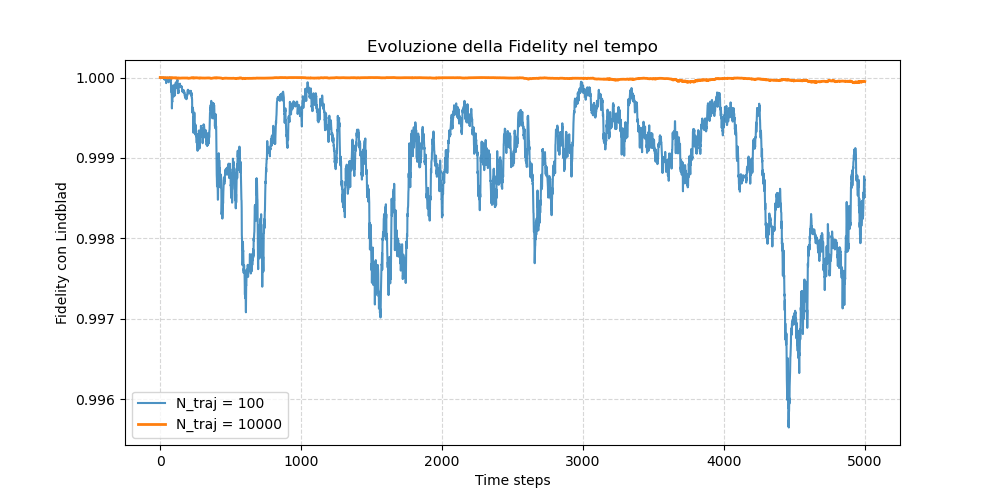

In [24]:
print(f"Theta   : {[f'{np.degrees(t):.3f}°' for t in results.keys()]}")
theta = np.radians(cfg['thetas_deg'][2])  # change angle
plt.close()
# In N_traj_list: l'indice 0 è 100 traiettorie, l'indice -1 è 10000 traiettorie
plt.figure(figsize=(10, 5))
plt.plot(Fidelity_tensors[theta][0, :], label='N_traj = 100', alpha=0.8)
plt.plot(Fidelity_tensors[theta][-1, :], label='N_traj = 10000', linewidth=2)

plt.xlabel("Time steps")
plt.ylabel("Fidelity con Lindblad")
plt.title("Evoluzione della Fidelity nel tempo")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Fidelity average over time for different Number of Trajectories

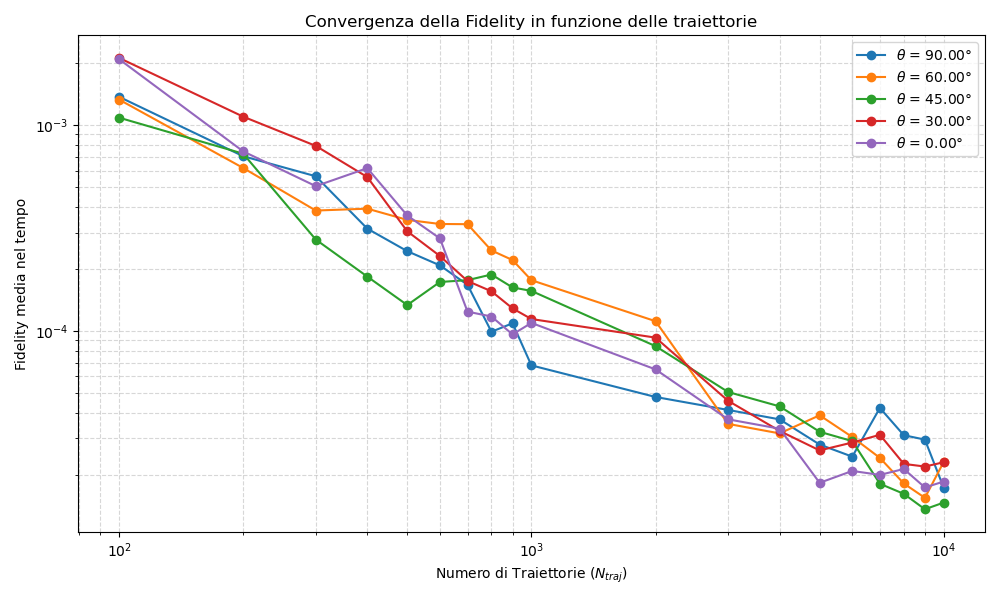

In [35]:
plt.figure(figsize=(10, 6))

# Cicliamo su tutti gli angoli disponibili nei tuoi risultati
for theta, fid_matrix in Fidelity_tensors.items():
    
    # fid_matrix ha dimensione (N_traj, time_steps)
    # Calcoliamo la media lungo la dimensione del tempo (axis=1)
    fidelity_time_avg = np.mean(fid_matrix, axis=1)
    fidelity_time_avg = 1 - fidelity_time_avg
    
    # Convertiamo l'angolo in gradi per la legenda
    theta_deg = np.degrees(theta)
    
    # Plottiamo la curva per questo specifico angolo
    plt.plot(N_traj_list, fidelity_time_avg, marker='o', linestyle='-', 
             label=f'$\\theta$ = {theta_deg:.2f}°')

plt.xlabel("Numero di Traiettorie ($N_{traj}$)")
plt.ylabel("Fidelity media nel tempo")
plt.title("Convergenza della Fidelity in funzione delle traiettorie")

# scala logaritmica per l'asse X 
plt.xscale('log')
plt.yscale('log')

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

### Minimal Fidelity for different Number of Trajectories

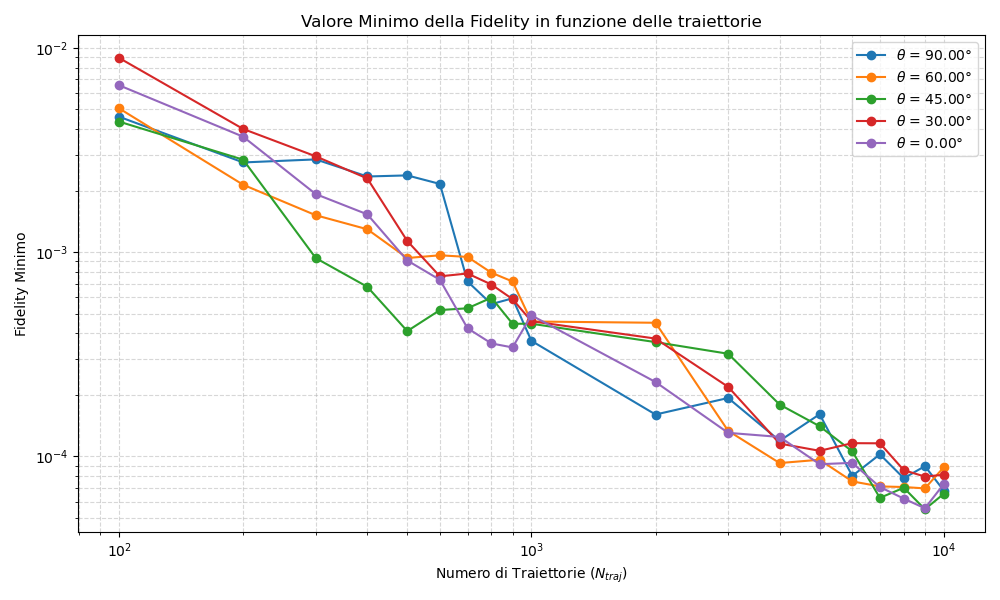

In [34]:
plt.figure(figsize=(10, 6))

# Cicliamo su tutti gli angoli disponibili nei tuoi risultati
for theta, fid_matrix in Fidelity_tensors.items():
    
    # fid_matrix ha dimensione (N_traj, time_steps)
    # Calcoliamo il Minimo lungo la dimensione del tempo (axis=1)
    fidelity_min = np.min(fid_matrix, axis=1)
    fidelity_min = 1 - fidelity_min
    
    # Convertiamo l'angolo in gradi per la legenda
    theta_deg = np.degrees(theta)
    
    # Plottiamo la curva per questo specifico angolo
    plt.plot(N_traj_list, fidelity_min, marker='o', linestyle='-', 
             label=f'$\\theta$ = {theta_deg:.2f}°')

plt.xlabel("Numero di Traiettorie ($N_{traj}$)")
plt.ylabel("Fidelity Minimo")
plt.title("Valore Minimo della Fidelity in funzione delle traiettorie")

# scala logaritmica per l'asse X 
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

## Trace Distance calculation

In [14]:
# Creiamo il dizionario per salvare i tensori di Trace Distance per ogni angolo
Trace_Distance_tensors = {}

# Ricaviamo le dimensioni dal primo tensore disponibile
primo_theta = list(rho_tensors.keys())[0]
num_traj = rho_tensors[primo_theta].shape[0]
time_steps = rho_tensors[primo_theta].shape[1]

print("Inizio il calcolo della Trace Distance...")

# Iteriamo su tutti gli angoli calcolati
for theta, rho_tensor in rho_tensors.items():
    
    # Inizializziamo una matrice 2D per le trace distance: (N_traj, time_steps)
    td_matrix = np.zeros((num_traj, time_steps), dtype=np.float64)
    
    for i in range(num_traj):
        for t in range(time_steps):
            
            # Estraiamo le matrici 2x2 per questo step
            rho_t = rho_tensor[i, t, :, :]
            sigma_t = rho_Lindblad[t, :, :]
            
            # Calcoliamo la Trace Distance usando la funzione analitica per Qubit
            td_matrix[i, t] = trace_distance_qubit(rho_t, sigma_t)
            
    # Salviamo la matrice nel dizionario
    Trace_Distance_tensors[theta] = td_matrix

print("Calcolo Trace Distance completato!")

Inizio il calcolo della Trace Distance...
Calcolo Trace Distance completato!


### Trace Distance in Time

Theta   : ['90.000°', '60.000°', '45.000°', '30.000°', '0.000°']


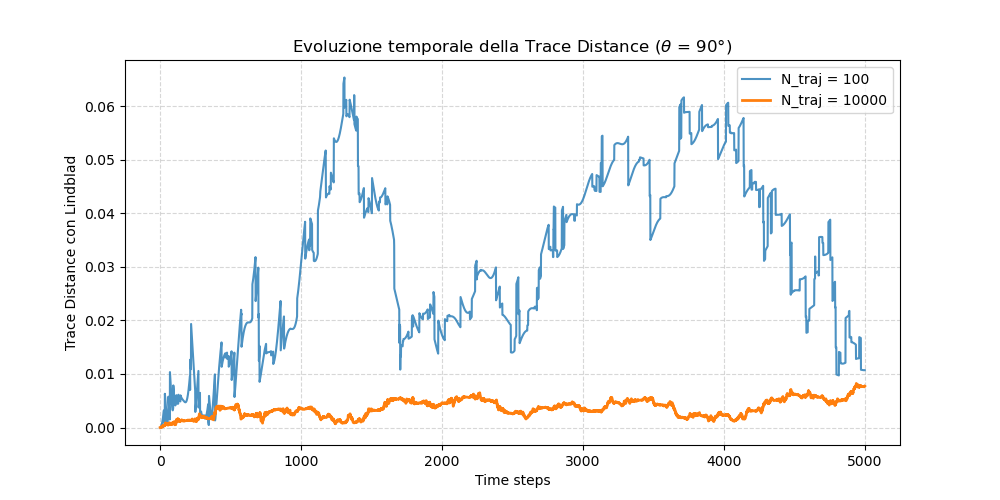

In [17]:
print(f"Theta   : {[f'{np.degrees(t):.3f}°' for t in results.keys()]}")
theta = np.radians(cfg['thetas_deg'][0])  # change angle

plt.figure(figsize=(10, 5))

# Trace Distance per N_traj basso (indice 0 della lista, es. 100 traiettorie)
plt.plot(Trace_Distance_tensors[theta][0, :], label='N_traj = 100', alpha=0.8)

# Trace Distance per N_traj alto (ultimo indice della lista, es. 10000 traiettorie)
plt.plot(Trace_Distance_tensors[theta][-1, :], label='N_traj = 10000', linewidth=2)

# Formattazione del grafico
plt.xlabel("Time steps")
plt.ylabel("Trace Distance con Lindblad")
plt.title(f"Evoluzione temporale della Trace Distance ($\\theta$ = {np.degrees(theta):.0f}°)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Trace Distance average over time for different Number of Trajectories

/tmp/ipykernel_201092/2372560024.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


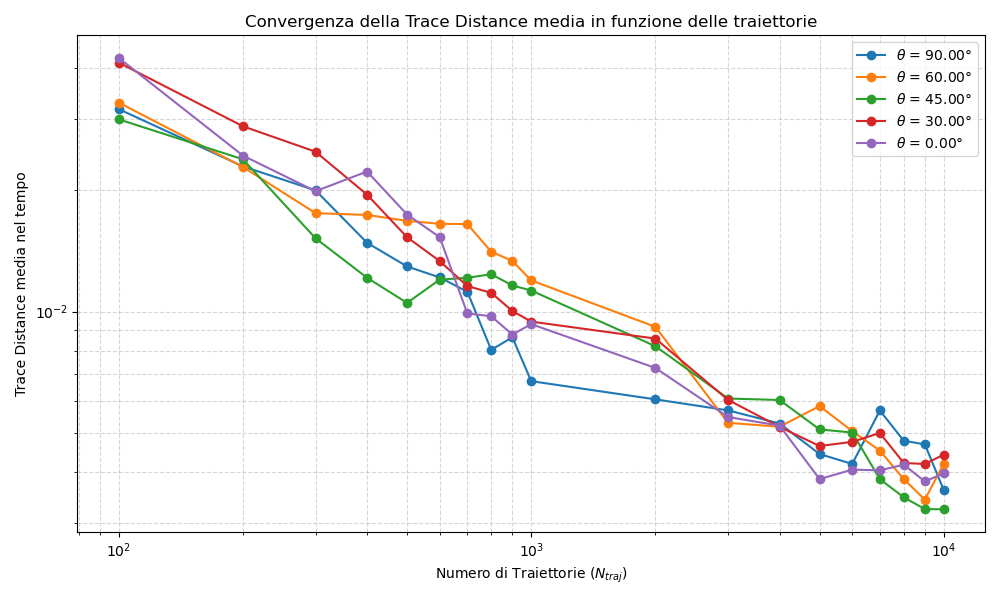

In [36]:
plt.figure(figsize=(10, 6))

# Cicliamo su tutti gli angoli disponibili
for theta, td_matrix in Trace_Distance_tensors.items():
    
    # Calcoliamo la MEDIA lungo la dimensione del tempo (axis=1)
    td_time_avg = np.mean(td_matrix, axis=1)
    
    # Convertiamo l'angolo in gradi per la legenda
    theta_deg = np.degrees(theta)
    
    # Plottiamo la curva
    plt.plot(N_traj_list, td_time_avg, marker='o', linestyle='-', 
             label=f'$\\theta$ = {theta_deg:.2f}°')

# Formattazione
plt.xlabel("Numero di Traiettorie ($N_{traj}$)")
plt.ylabel("Trace Distance media nel tempo")
plt.title("Convergenza della Trace Distance media in funzione delle traiettorie")

# Scala logaritmica
plt.xscale('log')
plt.yscale('log')

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

### Maximal Trace Distance for different Number of Trajectories

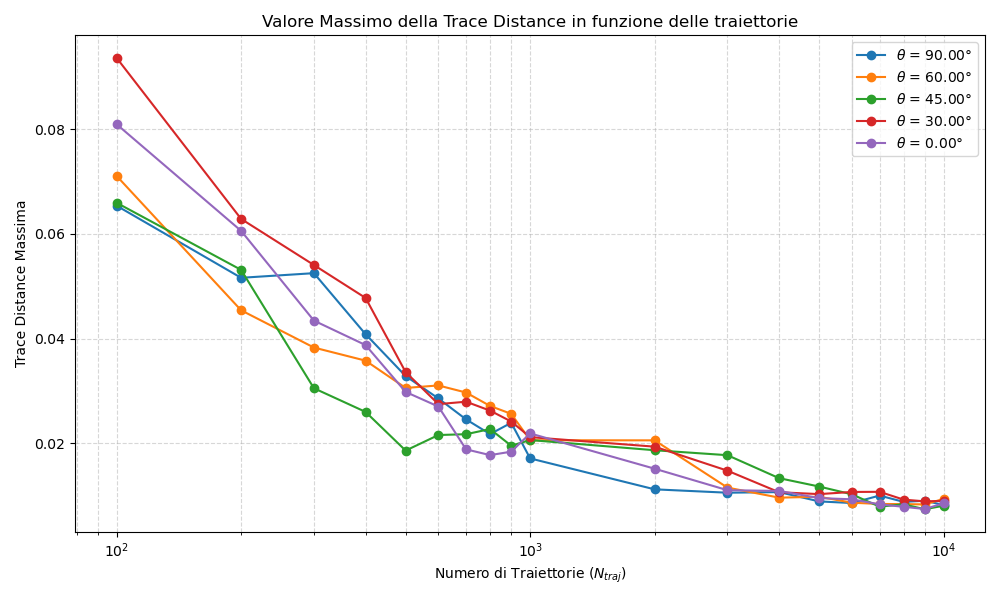

In [16]:
plt.figure(figsize=(10, 6))

# Cicliamo su tutti gli angoli disponibili
for theta, td_matrix in Trace_Distance_tensors.items():
    
    # Calcoliamo il MASSIMO lungo la dimensione del tempo (axis=1)
    td_max = np.max(td_matrix, axis=1)
    
    # Convertiamo l'angolo in gradi per la legenda
    theta_deg = np.degrees(theta)
    
    # Plottiamo la curva
    plt.plot(N_traj_list, td_max, marker='o', linestyle='-', 
             label=f'$\\theta$ = {theta_deg:.2f}°')

# Formattazione
plt.xlabel("Numero di Traiettorie ($N_{traj}$)")
plt.ylabel("Trace Distance Massima")
plt.title("Valore Massimo della Trace Distance in funzione delle traiettorie")

# Scala logaritmica
plt.xscale('log')

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

### Fuchs-van de Graaf inequality

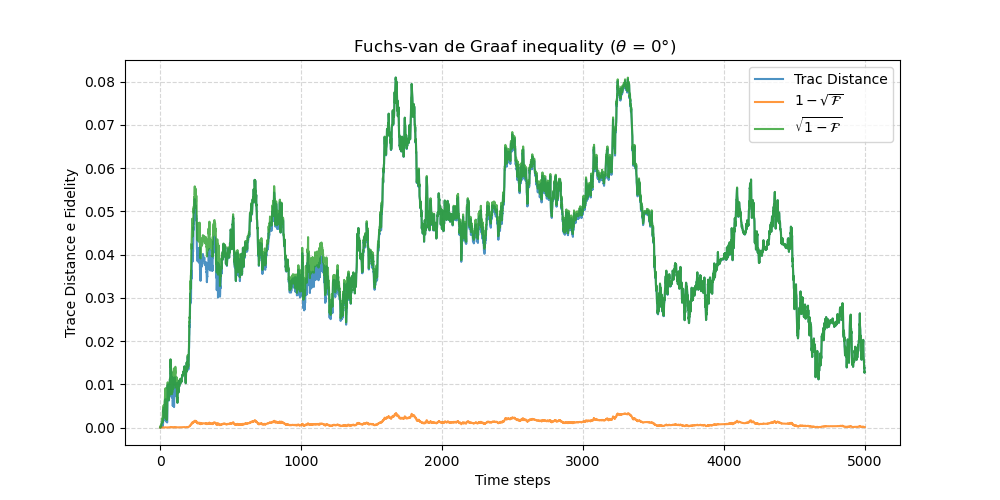

In [39]:
lower = 1 - np.sqrt(Fidelity_tensors[theta][0, :])
upper = np.sqrt(np.clip(1 - Fidelity_tensors[theta][0, :], 0.0, 1.0))

plt.figure(figsize=(10, 5))

# Trace Distance per N_traj basso (indice 0 della lista, es. 100 traiettorie)
plt.plot(Trace_Distance_tensors[theta][0, :], label='Trac Distance', alpha=0.8)
plt.plot(lower, label=r"$ 1 - \sqrt{\mathcal{F}} $", alpha=0.8)
plt.plot(upper, label=r"$ \sqrt{1 - \mathcal{F}} $", alpha=0.8)

# Formattazione del grafico
plt.xlabel("Time steps")
plt.ylabel("Trace Distance e Fidelity")
plt.title(f" Fuchs-van de Graaf inequality ($\\theta$ = {np.degrees(theta):.0f}°)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Mostriamo il plot
plt.show()